# Conservation évolutive de l'actine ↔ enfouissement aux interfaces

**Question :** les résidus de l'actine (P60709) les plus contraints par l'évolution (score ProteoCast/GEMME) sont-ils ceux les plus enfouis aux interfaces (% ASA) ?

**Méthode (fixée) :**
- Conservation = `-mean(Variant_score)` par résidu (ProteoCast, plus grand = plus conservé).
- % ASA = enfouissement aux interfaces, **moyenne corrigée AVEC zéros**, **normalisée par cluster C70** (cohérent avec les autres analyses du projet). Toutes les actines sont utilisées (homo = des 2 côtés).
- homo = actine–actine (filament) ; hétéro = actine–ABP. Combiné = `max(homo, hétéro)` par position.
- Corrélations de **Spearman** sur les **positions d'interface**.

In [1]:
from pathlib import Path
import re, bisect
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROTEO   = ROOT / 'proteocast_evalue0_actine' / '4.query_ProteoCast.csv'
ALL_DATA = ROOT / 'data/filtered/filtered_all_data.csv'
T1 = ROOT / 'data/filtered/details/1.interactions.csv'
T3 = ROOT / 'data/filtered/details/3.interface_residues.csv'
T4 = ROOT / 'data/filtered/details/4.inter-residue_contacts.csv'
C70 = ROOT / 'data/filtered/patches_infos_cluster_data_70.csv'
P60709 = ('MDDDIAALVVDNGSGMCKAGFAGDDAPRAVFPSIVGRPRHQGVMVGMGQKDSYVGDEAQSKRGILTLKYPIEHGIVTNWDD'
          'MEKIWHHTFYNELRVAPEEHPVLLTEAPLNPKANREKMTQIMFETFNTPAMYVAIQAVLSLYASGRTTGIVMDSGDGVTHTV'
          'PIYEGYALPHAILRLDLAGRDLTDYLMKILTERGYSFTTTAEREIVRDIKEKLCYVALDFEQEMATAASSSSLEKSYELPDG'
          'QVITIGNERFRCPEALFQPSFLGMESCGIHETTFNSIMKCDVDIRKDLYANTVLSGGTTMYPGIADRMQKEITALAPSTMKI'
          'KIIAPPERKYSVWIGGSILASLSTFQQMWISKQEYDESGPSIVHRKCF')
df_all = pd.read_csv(ALL_DATA, low_memory=False)
df_all['s1_sequence'] = df_all['s1_sequence'].astype(str)
df_all['s2_actine'] = df_all['s2_actine'].fillna(False).astype(bool)
print('Donnees chargees - actine P60709 :', len(P60709), 'residus')

Donnees chargees - actine P60709 : 375 residus


## 1. Correspondance position P60709 ↔ numérotation canonique

In [2]:
p60709_chains = set(df_all.loc[df_all['s1_sequence'] == P60709, 'subunit_1'])
df3 = pd.read_csv(T3)
df3['canon'] = pd.to_numeric(df3['residue_number_canon_mafft'], errors='coerce')
df3['seqn'] = pd.to_numeric(df3['residue_number_sequence'], errors='coerce')
m = df3[df3['chain'].isin(p60709_chains)].dropna(subset=['canon', 'seqn'])
seq2canon = m.groupby('seqn')['canon'].agg(lambda x: int(x.mode().iloc[0])).to_dict()
seq2canon = {int(k): int(v) for k, v in seq2canon.items()}
ks = sorted(seq2canon); full = {}
for p in range(1, 376):
    if p in seq2canon:
        full[p] = seq2canon[p]; continue
    i = bisect.bisect_left(ks, p)
    cand = ([ks[i]] if i < len(ks) else []) + ([ks[i-1]] if i > 0 else [])
    nn = min(cand, key=lambda q: abs(q - p)); full[p] = seq2canon[nn] + (p - nn)
seq2canon = full; canon2seq = {c: s for s, c in seq2canon.items()}
print('mapping P60709 <-> canon :', len(seq2canon), '/375')

mapping P60709 <-> canon : 375 /375


## 2. Conservation par résidu (ProteoCast)

In [3]:
pc = pd.read_csv(PROTEO)
res = (pc.groupby('Residue')
         .agg(mean_vs=('Variant_score', 'mean'), min_vs=('Variant_score', 'min'),
              frac_impactful=('Variant_class', lambda s: (s == 'impactful').mean()),
              residue_class=('Residue_class', 'first'))
         .reset_index())
res['conservation'] = -res['mean_vs']
cons = res.set_index('Residue')['conservation']
cons_full = cons.reindex(range(1, 376))
print('Conservation calculee pour', len(res), 'residus (plus grand = plus conserve)')
res.head()

Conservation calculee pour 375 residus (plus grand = plus conserve)


,Residue,mean_vs,min_vs,frac_impactful,residue_class,conservation
0,1,-1.418471,-1.683135,0.0,tolerant,1.418471
1,2,-1.764653,-2.821884,0.0,tolerant,1.764653
2,3,-2.018463,-3.218546,0.0,tolerant,2.018463
3,4,-2.109647,-3.619279,0.0,tolerant,2.109647
4,5,-1.323035,-3.247757,0.0,tolerant,1.323035


## 3. Interactions : homo (filament) / hétéro (ABP) + cluster C70

In [4]:
di = pd.read_csv(T1).merge(
    df_all[['subunit_1', 'subunit_2', 's2_actine', 'subunit_2_title', 's2_sequence_cluster_70', 's2_sequence_cluster_40',
            's1_binding_site_cluster_data_70', 's2_binding_site_cluster_data_70']].drop_duplicates(),
    left_on=['chain_A_id', 'chain_B_id'], right_on=['subunit_1', 'subunit_2'], how='left')
di['s2_actine'] = di['s2_actine'].fillna(False).astype(bool)
di['itype'] = np.where(di['s2_actine'], 'homo', 'hetero')
dc = pd.read_csv(C70)
def parse_ids(s):
    s = re.sub(r'np\.int64\((\d+)\)', r'\1', str(s)); return [int(x) for x in re.findall(r'\d+', s)]
iid2patch = {}
for _, r in dc.iterrows():
    for iid in parse_ids(r['ids_interactions']):
        iid2patch[iid] = r['patch']
di['patch'] = di['interaction_id'].map(iid2patch)
print('interactions :', len(di), '|', di['itype'].value_counts().to_dict())

interactions : 2058 | {'homo': 1266, 'hetero': 792}


## 4. % ASA par position — moyenne corrigée (avec zéros), normalisée C70
Pour les contacts homo (actine–actine), l'actine est des deux côtés → on prend A et B.

In [5]:
d4 = pd.read_csv(T4)
d4['caA'] = pd.to_numeric(d4['residue_A_canon_mafft'], errors='coerce')
d4['caB'] = pd.to_numeric(d4['residue_B_canon_mafft'], errors='coerce')
d4['asaA'] = pd.to_numeric(d4['asa_pct_A'], errors='coerce')
d4['asaB'] = pd.to_numeric(d4['asa_pct_B'], errors='coerce')
d4 = d4.join(di.set_index('interaction_id')[['itype', 'patch']], on='interaction_id').dropna(subset=['patch'])
def _side(dd, cc, aa, it):
    s = dd.dropna(subset=[cc, aa])
    return pd.DataFrame({'interaction_id': s['interaction_id'], 'patch': s['patch'],
                         'canon': s[cc].astype(int), 'asa': s[aa], 'itype': it})
het = d4[d4.itype == 'hetero']; ho = d4[d4.itype == 'homo']
OBS = pd.concat([_side(het, 'caA', 'asaA', 'hetero'),
                 _side(ho, 'caA', 'asaA', 'homo'), _side(ho, 'caB', 'asaB', 'homo')], ignore_index=True)

def equitable(df_t):
    l1 = df_t.groupby(['patch', 'interaction_id', 'canon'])['asa'].max().reset_index()
    npatch = l1.groupby('patch')['interaction_id'].nunique()
    s = l1.groupby(['patch', 'canon'])['asa'].sum()
    l2 = s / s.index.get_level_values('patch').map(npatch)
    return l2.groupby('canon').mean()

# Moyennes par type (TOUS les homo / TOUS les hetero) -> pour le combine
homo_prof = equitable(OBS[OBS.itype == 'homo'])
# ABP = par proteine (s2_sequence_cluster_70) : moyenne par ABP (zeros inclus) -> MAX entre ABP
iid2abp = di.set_index('interaction_id')['s2_sequence_cluster_70']
_oh = OBS[OBS.itype == 'hetero'].copy(); _oh['abp'] = _oh['interaction_id'].map(iid2abp)
_oh = _oh.dropna(subset=['abp'])
_l1 = _oh.groupby(['abp', 'interaction_id', 'canon'])['asa'].max().reset_index()
_nab = _l1.groupby('abp')['interaction_id'].nunique()
_sab = _l1.groupby(['abp', 'canon'])['asa'].sum()
_per_abp = _sab / _sab.index.get_level_values('abp').map(_nab)   # moyenne par ABP (zeros)
hetero_prof = _per_abp.groupby('canon').mean()                   # MOYENNE entre ABP

# HOMO4 = les 4 interfaces actine-actine (6685_1..4) -> pour le panneau/correlation homo
MAIN_BS = ['6685_1', '6685_2', '6685_3', '6685_4']
t3 = df3.merge(di[['interaction_id', 'chain_A_id', 'chain_B_id', 's2_actine',
                   's1_binding_site_cluster_data_70', 's2_binding_site_cluster_data_70']],
               on='interaction_id', how='inner')
t3 = t3[t3['s2_actine']].copy()
t3['role'] = np.where(t3['chain'] == t3['chain_A_id'], 'S1', np.where(t3['chain'] == t3['chain_B_id'], 'S2', None))
t3['bs'] = np.where(t3['role'] == 'S1', t3['s1_binding_site_cluster_data_70'], t3['s2_binding_site_cluster_data_70'])
t3['asa'] = pd.to_numeric(t3['buried_ASA_percent'].astype(str).str.replace('%', '', regex=False), errors='coerce')
t3['canon'] = pd.to_numeric(t3['residue_number_canon_mafft'], errors='coerce')
t3 = t3.dropna(subset=['canon', 'asa', 'bs']); t3['canon'] = t3['canon'].astype(int)
bs_profiles = {}
for bs in MAIN_BS:
    sub = t3[t3.bs == bs]
    l1 = sub.groupby(['interaction_id', 'chain', 'canon'])['asa'].max().reset_index()
    nunit = l1.groupby(['interaction_id', 'chain']).ngroups
    pc = l1.groupby('canon')['asa'].sum() / nunit
    bs_profiles[bs] = pd.Series({canon2seq[c]: v for c, v in pc.items() if c in canon2seq}).reindex(range(1, 376))
homo4 = pd.concat(bs_profiles, axis=1).max(axis=1)   # MAX sur les 4 clusters (interfaces differentes)

df = res.copy(); df['canon'] = df['Residue'].map(seq2canon)
df['homo_asa'] = df['Residue'].map(homo4).fillna(0.0)              # homo = 4 interfaces (viz/correl)
df['homo_all_asa'] = df['canon'].map(homo_prof).fillna(0.0)        # TOUS les homo (pour le combine)
df['hetero_asa'] = df['canon'].map(hetero_prof).fillna(0.0)        # TOUS les hetero
df['combined_asa'] = df[['homo_asa', 'hetero_asa']].max(axis=1)   # max(homo4, ABP) par position  # max(tous homo, tous hetero) par position
df['at_homo'] = df['homo_asa'] > 0; df['at_hetero'] = df['hetero_asa'] > 0; df['at_interface'] = df['combined_asa'] > 0
print('homo (panneau)=homo4 :', df.at_homo.sum(), '| hetero :', df.at_hetero.sum(),
      '| combine (tous homo+hetero) :', df.at_interface.sum())

homo (panneau)=homo4 : 137 | hetero : 295 | combine (tous homo+hetero) : 302


## 5. RSA (enfouissement intrinsèque) — pour le contrôle du cœur

En interaction : n=302, conservation moy = 4.064
Jamais en interaction : n=73, conservation moy = 4.802
Mann-Whitney (two-sided) : p=2.26e-06
ATTENTION : 72/73 des positions jamais en interaction = coeur enfoui (RSA<20%)
-> cette comparaison reflete surtout surface vs coeur, pas interface vs non-interface


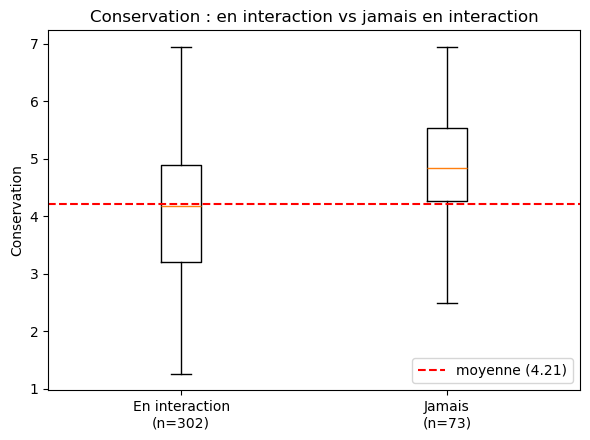

In [6]:
from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley
from Bio.Align import PairwiseAligner
PDB_ACTIN = ROOT / 'data/filtered/details/structures_files/pairwise/1004_8iah_E_F.pdb'
_3to1 = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E','GLY':'G','HIS':'H','ILE':'I',
         'LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V'}
MAXASA = {'A':129,'R':274,'N':195,'D':193,'C':167,'E':223,'Q':225,'G':104,'H':224,'I':197,'L':201,'K':236,
          'M':224,'F':240,'P':159,'S':155,'T':172,'W':285,'Y':263,'V':174}
model = PDBParser(QUIET=True).get_structure('a', str(PDB_ACTIN))[0]
for ch in list(model):
    if ch.id != 'A': model.detach_child(ch.id)
ShrakeRupley().compute(model, level='R')
seq = ''; sasa = []
for rr in model['A']:
    if rr.resname in _3to1 and rr.id[0] == ' ':
        seq += _3to1[rr.resname]; sasa.append(rr.sasa)
rsa = [s / MAXASA[a] for s, a in zip(sasa, seq)]
al = PairwiseAligner(); al.mode = 'global'; al.match_score, al.mismatch_score = 2, -1
al.open_gap_score, al.extend_gap_score = -10, -0.5
aln = al.align(P60709, seq)[0]; rsa_p = {}
for (a0, a1), (b0, b1) in zip(aln.aligned[0], aln.aligned[1]):
    for k in range(a1 - a0): rsa_p[a0 + k + 1] = rsa[b0 + k]
df['rsa'] = df['Residue'].map(rsa_p)

# === En interaction (quelconque) vs JAMAIS en interaction ===
ever = {canon2seq[c] for c in OBS['canon'].unique() if c in canon2seq}
df['ever_iface'] = df['Residue'].isin(ever)
from scipy.stats import mannwhitneyu
gi = df.loc[df.ever_iface, 'conservation']; gj = df.loc[~df.ever_iface, 'conservation']
u, pp = mannwhitneyu(gi, gj, alternative='two-sided')
print(f'En interaction : n={len(gi)}, conservation moy = {gi.mean():.3f}')
print(f'Jamais en interaction : n={len(gj)}, conservation moy = {gj.mean():.3f}')
print(f'Mann-Whitney (two-sided) : p={pp:.2e}')
ncore = (df.loc[~df.ever_iface, 'rsa'] < 0.20).sum()
print(f'ATTENTION : {ncore}/{len(gj)} des positions jamais en interaction = coeur enfoui (RSA<20%)')
print('-> cette comparaison reflete surtout surface vs coeur, pas interface vs non-interface')
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.boxplot([gi, gj], labels=[f'En interaction\n(n={len(gi)})', f'Jamais\n(n={len(gj)})'])
ax.axhline(df['conservation'].mean(), color='red', ls='--', label=f'moyenne ({df.conservation.mean():.2f})')
ax.set_ylabel('Conservation'); ax.set_title('Conservation : en interaction vs jamais en interaction'); ax.legend()
plt.tight_layout(); plt.show()

### Relation de base : conservation vs RSA (pourquoi le cœur > la surface)

Démontre que la conservation **diminue avec l'accessibilité** : le cœur enfoui (RSA basse) est plus conservé que la surface (raison structurale). C'est ce qui explique que (1) les résidus jamais en interaction (= cœur) soient plus conservés, et (2) le pic à bas ASA. → justifie le contrôle RSA.

Conservation vs RSA : Spearman r=-0.453 (p=2.3e-20) n=374
(r negatif = plus expose -> moins conserve ; donc enfoui -> plus conserve)


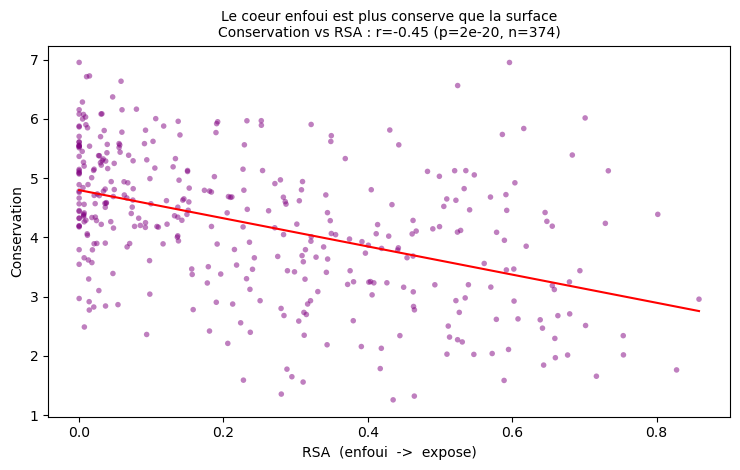

In [7]:
sub = df.dropna(subset=['rsa']).copy()
rs, ps = stats.spearmanr(sub['rsa'], sub['conservation'])
print(f'Conservation vs RSA : Spearman r={rs:+.3f} (p={ps:.1e}) n={len(sub)}')
print('(r negatif = plus expose -> moins conserve ; donc enfoui -> plus conserve)')
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(sub['rsa'], sub['conservation'], s=16, alpha=0.5, color='purple', edgecolor='none')
z = np.polyfit(sub['rsa'], sub['conservation'], 1); xx = np.linspace(sub['rsa'].min(), sub['rsa'].max(), 50)
ax.plot(xx, np.polyval(z, xx), 'r-', lw=1.5)
ax.set_xlabel('RSA  (enfoui  ->  expose)'); ax.set_ylabel('Conservation')
ax.set_title(f'Le coeur enfoui est plus conserve que la surface\nConservation vs RSA : r={rs:+.2f} (p={ps:.0e}, n={len(sub)})', fontsize=10)
plt.tight_layout(); plt.show()

### Vérification : « hors interface » = cœur hydrophobe enfoui

(1) Les résidus hors interface sont-ils enfouis (RSA basse) ? (2) Le cœur est-il hydrophobe ?

=== RSA : interface vs hors interface ===
  interface       : RSA moy 0.298 (n=301)
  hors interface  : RSA moy 0.026 (n=73)  -> 99% enfouis (RSA<20%)
  Mann-Whitney p=2.1e-27
  corr at_interface vs RSA : r=+0.485 (p=1.7e-23)

=== % hydrophobe (AVILMFWC) ===
  coeur enfoui (RSA<20%) : 54% (n=190)
  surface (RSA>=20%)     : 23% (n=184)


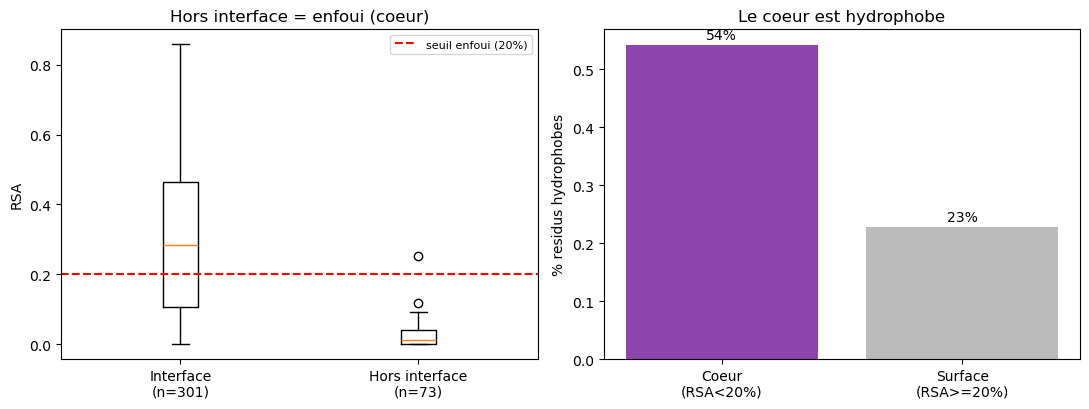

In [8]:
from scipy.stats import mannwhitneyu, pointbiserialr
d = df.dropna(subset=['rsa']).copy()
d['aa'] = d['Residue'].apply(lambda x: P60709[int(x) - 1])
HYD = set('AVILMFWC')

gi = d.loc[d.at_interface, 'rsa']; gn = d.loc[~d.at_interface, 'rsa']
print('=== RSA : interface vs hors interface ===')
print(f'  interface       : RSA moy {gi.mean():.3f} (n={len(gi)})')
print(f'  hors interface  : RSA moy {gn.mean():.3f} (n={len(gn)})  -> {(gn<0.20).mean():.0%} enfouis (RSA<20%)')
print(f'  Mann-Whitney p={mannwhitneyu(gi, gn).pvalue:.1e}')
r, pp = pointbiserialr(d['at_interface'].astype(int), d['rsa'])
print(f'  corr at_interface vs RSA : r={r:+.3f} (p={pp:.1e})')

core = d[d['rsa'] < 0.20]; surf = d[d['rsa'] >= 0.20]
fc, fs = core['aa'].isin(HYD).mean(), surf['aa'].isin(HYD).mean()
print('\n=== % hydrophobe (AVILMFWC) ===')
print(f'  coeur enfoui (RSA<20%) : {fc:.0%} (n={len(core)})')
print(f'  surface (RSA>=20%)     : {fs:.0%} (n={len(surf)})')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].boxplot([gi, gn], labels=[f'Interface\n(n={len(gi)})', f'Hors interface\n(n={len(gn)})'])
axes[0].axhline(0.20, color='red', ls='--', label='seuil enfoui (20%)')
axes[0].set_ylabel('RSA'); axes[0].set_title('Hors interface = enfoui (coeur)'); axes[0].legend(fontsize=8)
axes[1].bar(['Coeur\n(RSA<20%)', 'Surface\n(RSA>=20%)'], [fc, fs], color=['#8e44ad', '#bbbbbb'])
axes[1].set_ylabel('% residus hydrophobes'); axes[1].set_title('Le coeur est hydrophobe')
for i, v in enumerate([fc, fs]): axes[1].text(i, v + 0.01, f'{v:.0%}', ha='center')
plt.tight_layout(); plt.show()

## 6. Corrélations conservation ↔ % ASA (positions d'interface)

In [9]:
def corr_report(sub, xc):
    s = sub[[xc, 'conservation']].dropna()
    rs, ps = stats.spearmanr(s[xc], s['conservation']); rp, pp = stats.pearsonr(s[xc], s['conservation'])
    print(f'  {xc:13} | Spearman r={rs:+.3f} (p={ps:.1e}) | Pearson r={rp:+.3f} (p={pp:.1e}) | n={len(s)}')
print('Conservation vs % ASA (interface seule) :')
corr_report(df[df.at_homo], 'homo_asa')
corr_report(df[df.at_hetero], 'hetero_asa')
corr_report(df[df.at_interface], 'combined_asa')

Conservation vs % ASA (interface seule) :
  homo_asa      | Spearman r=+0.245 (p=3.9e-03) | Pearson r=+0.277 (p=1.1e-03) | n=137
  hetero_asa    | Spearman r=+0.230 (p=6.8e-05) | Pearson r=+0.236 (p=4.4e-05) | n=295
  combined_asa  | Spearman r=+0.250 (p=1.1e-05) | Pearson r=+0.239 (p=2.6e-05) | n=302


## 7. Corrélations partielles (spécificité ABP + contrôle RSA)

In [10]:
def partial_spearman(sub, x, y, z):
    s = sub[[x, y, z]].dropna()
    rx, ry, rz = stats.rankdata(s[x]), stats.rankdata(s[y]), stats.rankdata(s[z])
    Z = np.vstack([rz, np.ones_like(rz)]).T
    def rsd(a):
        c, *_ = np.linalg.lstsq(Z, a, rcond=None); return a - Z @ c
    r, p = stats.pearsonr(rsd(rx), rsd(ry)); return r, p, len(s)
si = df[df.at_interface]
r, p, n = partial_spearman(si, 'hetero_asa', 'conservation', 'homo_asa')
print(f'ABP | controle filament : r={r:+.3f} (p={p:.1e}) n={n}')
r, p, n = partial_spearman(si, 'homo_asa', 'conservation', 'hetero_asa')
print(f'filament | controle ABP : r={r:+.3f} (p={p:.1e}) n={n}')
sub = df.dropna(subset=['rsa'])
print('--- controle RSA (par type) ---')
for col, lab in [('hetero_asa', 'ABP'), ('homo_asa', 'filament'), ('combined_asa', 'combine')]:
    r, p, n = partial_spearman(sub[sub[col] > 0], col, 'conservation', 'rsa')
    print(f'{lab:9} | controle RSA : r={r:+.3f} (p={p:.1e}) n={n}')

ABP | controle filament : r=+0.196 (p=6.1e-04) n=302
filament | controle ABP : r=+0.103 (p=7.5e-02) n=302
--- controle RSA (par type) ---
ABP       | controle RSA : r=+0.169 (p=3.7e-03) n=294
filament  | controle RSA : r=+0.332 (p=7.5e-05) n=137
combine   | controle RSA : r=+0.345 (p=7.4e-10) n=301


## 8. Visualisations principales (nuage + tendance par quintile)

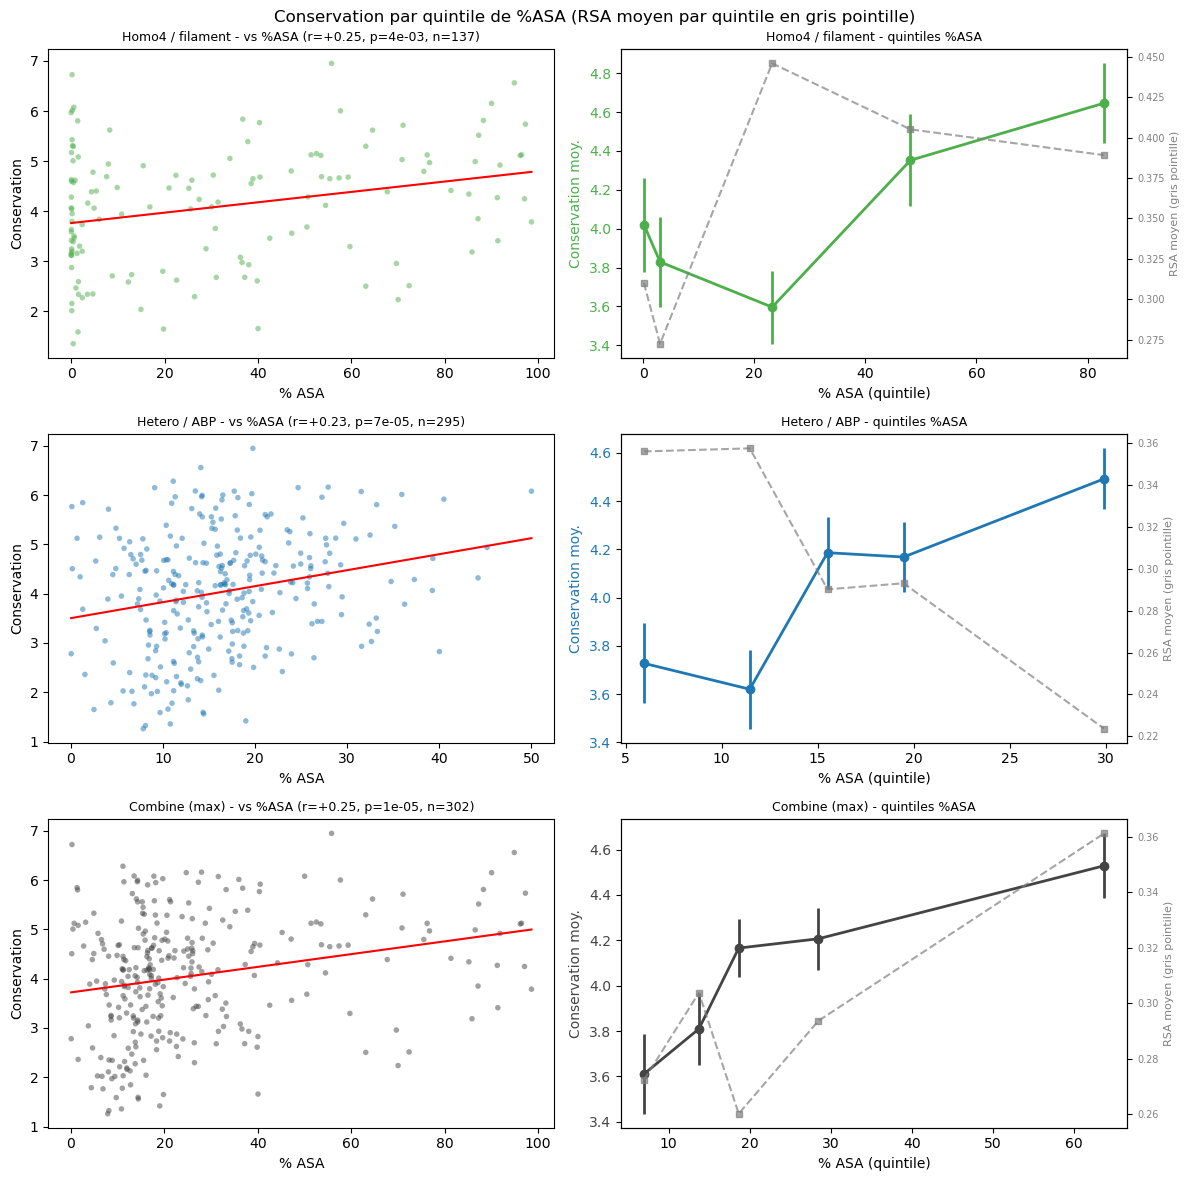

In [11]:
def _viz(ax_s, ax_q, col, titre, color):
    s = df[df[col] > 0]
    # Colonne 1 : conservation vs % ASA (nuage)
    ax_s.scatter(s[col], s['conservation'], s=16, alpha=0.5, color=color, edgecolor='none')
    z = np.polyfit(s[col], s['conservation'], 1); xx = np.linspace(s[col].min(), s[col].max(), 50)
    ax_s.plot(xx, np.polyval(z, xx), 'r-', lw=1.5)
    r, p = stats.spearmanr(s[col], s['conservation'])
    ax_s.set_title(f'{titre} - vs %ASA (r={r:+.2f}, p={p:.0e}, n={len(s)})', fontsize=9)
    ax_s.set_xlabel('% ASA'); ax_s.set_ylabel('Conservation')
    # Colonne 2 : quintiles %ASA (conservation, principal) + RSA moyen par quintile (gris pointille)
    q = s.copy(); q['qb'] = pd.qcut(q[col], 5, duplicates='drop')
    g = q.groupby('qb', observed=True).agg(cons=('conservation', 'mean'), sem=('conservation', 'sem'),
                                           rsa=('rsa', 'mean'), x=(col, 'mean'))
    ax_q.errorbar(g['x'], g['cons'], yerr=g['sem'], marker='o', lw=2, color=color, zorder=3)
    ax_q.set_xlabel('% ASA (quintile)'); ax_q.set_ylabel('Conservation moy.', color=color)
    ax_q.tick_params(axis='y', labelcolor=color)
    ax_q.set_title(f'{titre} - quintiles %ASA', fontsize=9)
    axr = ax_q.twinx()
    axr.plot(g['x'], g['rsa'], color='grey', ls='--', lw=1.5, alpha=0.7, marker='s', markersize=4, zorder=1)
    axr.set_ylabel('RSA moyen (gris pointille)', color='grey', fontsize=8)
    axr.tick_params(axis='y', labelcolor='grey', labelsize=7)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
for i, (col, t, c) in enumerate([('homo_asa', 'Homo4 / filament', '#4daf4a'),
                                 ('hetero_asa', 'Hetero / ABP', '#1f77b4'),
                                 ('combined_asa', 'Combine (max)', '#444444')]):
    _viz(axes[i, 0], axes[i, 1], col, t, c)
plt.suptitle('Conservation par quintile de %ASA (RSA moyen par quintile en gris pointille)', fontsize=12)
plt.tight_layout(); plt.show()

## 9. Les 4 interfaces actine–actine (binding-sites 6685_1..4)

binding_site  n_res  cons_moy
      6685_1     39  3.701659
      6685_2     40  3.926249
      6685_3     36  3.974509
      6685_4     53  4.482964


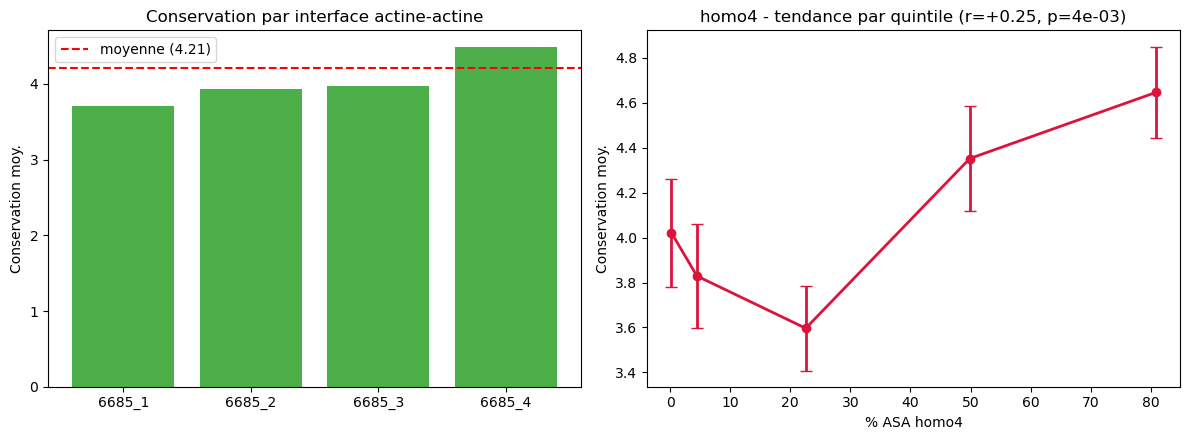

In [12]:
rows = [{'binding_site': bs, 'n_res': len(bs_profiles[bs].dropna()),
         'cons_moy': cons.reindex(bs_profiles[bs].dropna().index).mean()} for bs in MAIN_BS]
tab = pd.DataFrame(rows); print(tab.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(tab['binding_site'], tab['cons_moy'], color='#4daf4a')
axes[0].axhline(cons.mean(), color='red', ls='--', label=f'moyenne ({cons.mean():.2f})')
axes[0].set_ylabel('Conservation moy.'); axes[0].set_title('Conservation par interface actine-actine'); axes[0].legend()
s = homo4[homo4 > 0]; q = pd.DataFrame({'a': s, 'c': cons.reindex(s.index)}).dropna()
q['q'] = pd.qcut(q['a'], 5, duplicates='drop'); g = q.groupby('q', observed=True)['c'].agg(['mean', 'sem'])
rr, pp = stats.spearmanr(q['a'], q['c'])
axes[1].errorbar([iv.mid for iv in g.index], g['mean'], yerr=g['sem'], marker='o', capsize=4, lw=2, color='crimson')
axes[1].set_title(f'homo4 - tendance par quintile (r={rr:+.2f}, p={pp:.0e})')
axes[1].set_xlabel('% ASA homo4'); axes[1].set_ylabel('Conservation moy.')
plt.tight_layout(); plt.show()

Kruskal-Wallis (les 4 different globalement ?) : H=10.22, p=0.017

Comparaisons par paire (Mann-Whitney, two-sided ; Bonferroni = p x6) :
  6685_1 (3.70) vs 6685_2 (3.93) : p=0.427 | Bonf=1.000 ns
  6685_1 (3.70) vs 6685_3 (3.97) : p=0.379 | Bonf=1.000 ns
  6685_1 (3.70) vs 6685_4 (4.48) : p=0.002 | Bonf=0.011 *
  6685_2 (3.93) vs 6685_3 (3.97) : p=0.988 | Bonf=1.000 ns
  6685_2 (3.93) vs 6685_4 (4.48) : p=0.051 | Bonf=0.303 ns
  6685_3 (3.97) vs 6685_4 (4.48) : p=0.046 | Bonf=0.277 ns


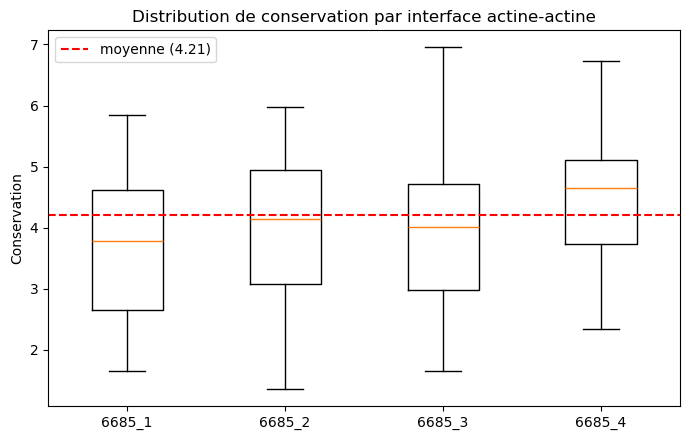

In [13]:
# Test : les 4 interfaces actine-actine diffèrent-elles en conservation ?
from scipy.stats import kruskal, mannwhitneyu
import itertools
groups = {bs: cons.reindex(bs_profiles[bs].dropna().index).dropna().values for bs in MAIN_BS}
H, pk = kruskal(*groups.values())
print(f'Kruskal-Wallis (les 4 different globalement ?) : H={H:.2f}, p={pk:.3f}')
print('\nComparaisons par paire (Mann-Whitney, two-sided ; Bonferroni = p x6) :')
for a, b in itertools.combinations(MAIN_BS, 2):
    u, pp = mannwhitneyu(groups[a], groups[b], alternative='two-sided')
    sig = '*' if pp * 6 < 0.05 else 'ns'
    print(f'  {a} ({np.mean(groups[a]):.2f}) vs {b} ({np.mean(groups[b]):.2f}) : p={pp:.3f} | Bonf={min(pp*6,1):.3f} {sig}')
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([groups[bs] for bs in MAIN_BS], labels=MAIN_BS)
ax.axhline(cons.mean(), color='red', ls='--', label=f'moyenne ({cons.mean():.2f})')
ax.set_ylabel('Conservation'); ax.set_title('Distribution de conservation par interface actine-actine'); ax.legend()
plt.tight_layout(); plt.show()

## 10. Conservation par famille d'ABP

           famille  n_intx  n_pos  cons_moy
      Cofiline/ADF     136     84  4.241583
Vinculine/Catenine      52    112  4.091299
     Tropomoduline       9    132  4.088664
Spectrine/actinine      46     84  4.084443
           Formine      30    114  4.021889
Toxine bacterienne     126    155  3.948328
            Arp2/3      65    165  3.926508
             Autre     116    227  3.918779
 Gelsoline/Villine       7    119  3.904944
           Myosine      93    102  3.896222
          Dematine      20    125  3.777571
          Coronine      91     98  3.685400


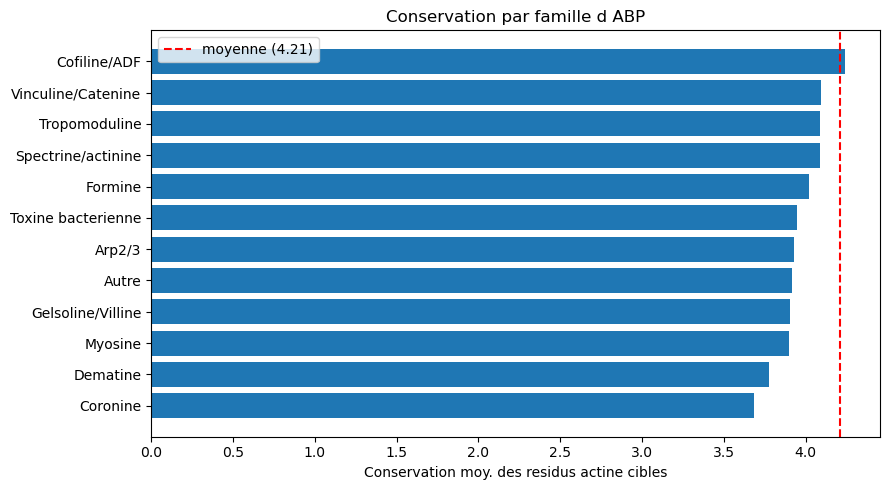

In [14]:
FAMILIES = [('Myosine', r'myosin'), ('Tropomyosine', r'tropomyosin'), ('Cofiline/ADF', r'cofilin|destrin'),
            ('Formine', r'formin|mdia|daam'), ('Gelsoline/Villine', r'gelsolin|villin|severin'),
            ('Arp2/3', r'arp2/3|actin-related protein 2|actin-related protein 3|arpc'),
            ('Spectrine/actinine', r'spectrin|actinin|fimbrin|plastin|filamin'), ('Coronine', r'coronin'),
            ('Vinculine/Catenine', r'vinculin|catenin|talin'), ('Toxine bacterienne', r'sipa|vop'),
            ('Profiline', r'profilin'), ('Thymosine/WH2', r'thymosin|wh2|ciboulot'),
            ('Tropomoduline', r'tropomodulin|leiomodin'), ('Dematine', r'dematin')]
def fam(t):
    t = str(t).lower()
    for n, pat in FAMILIES:
        if re.search(pat, t): return n
    return 'Autre'
di['family'] = di['subunit_2_title'].map(fam)
iid2fam = di.set_index('interaction_id')['family']
OBS_het = OBS[OBS.itype == 'hetero'].copy(); OBS_het['family'] = OBS_het['interaction_id'].map(iid2fam)
rows = []
for f, sub in OBS_het.groupby('family'):
    if sub['interaction_id'].nunique() < 3: continue
    prof = equitable(sub); pos = pd.Series({canon2seq[c]: v for c, v in prof.items() if c in canon2seq})
    rows.append({'famille': f, 'n_intx': sub['interaction_id'].nunique(), 'n_pos': len(pos),
                 'cons_moy': cons.reindex(pos.index).mean()})
fam_df = pd.DataFrame(rows).sort_values('cons_moy', ascending=False)
print(fam_df.to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 5)); fd = fam_df.sort_values('cons_moy')
ax.barh(fd['famille'], fd['cons_moy'], color='#1f77b4')
ax.axvline(cons.mean(), color='red', ls='--', label=f'moyenne ({cons.mean():.2f})')
ax.set_xlabel('Conservation moy. des residus actine cibles'); ax.set_title('Conservation par famille d ABP'); ax.legend()
plt.tight_layout(); plt.show()

In [15]:
# Test : les familles d'ABP diffèrent-elles en conservation des résidus ciblés ?
from scipy.stats import kruskal, mannwhitneyu
fam_groups = {}
for f, sub in OBS_het.groupby('family'):
    if sub['interaction_id'].nunique() < 3: continue
    prof = equitable(sub); pos = [canon2seq[c] for c in prof.index if c in canon2seq]
    vals = cons.reindex(pos).dropna().values
    if len(vals) >= 10: fam_groups[f] = vals
H, pk = kruskal(*fam_groups.values())
print(f'Kruskal-Wallis familles (different globalement ?) : H={H:.2f}, p={pk:.2e}')
order = sorted(fam_groups, key=lambda k: -np.mean(fam_groups[k]))
top, bot = order[0], order[-1]
u, pp = mannwhitneyu(fam_groups[top], fam_groups[bot], alternative='two-sided')
print(f'Plus conservee : {top} ({np.mean(fam_groups[top]):.2f}) | Moins : {bot} ({np.mean(fam_groups[bot]):.2f})')
print(f'{top} vs {bot} : Mann-Whitney p={pp:.3f}')

Kruskal-Wallis familles (different globalement ?) : H=18.17, p=7.77e-02
Plus conservee : Cofiline/ADF (4.24) | Moins : Coronine (3.69)
Cofiline/ADF vs Coronine : Mann-Whitney p=0.001


## 11. Positions « hub » — contactées par plusieurs familles d'ABP

nb clusters sequence 40% ABP vs conservation : r=-0.135 (p=2.0e-02) n=296
nb clusters sequence 70% ABP vs conservation : r=-0.137 (p=1.9e-02)


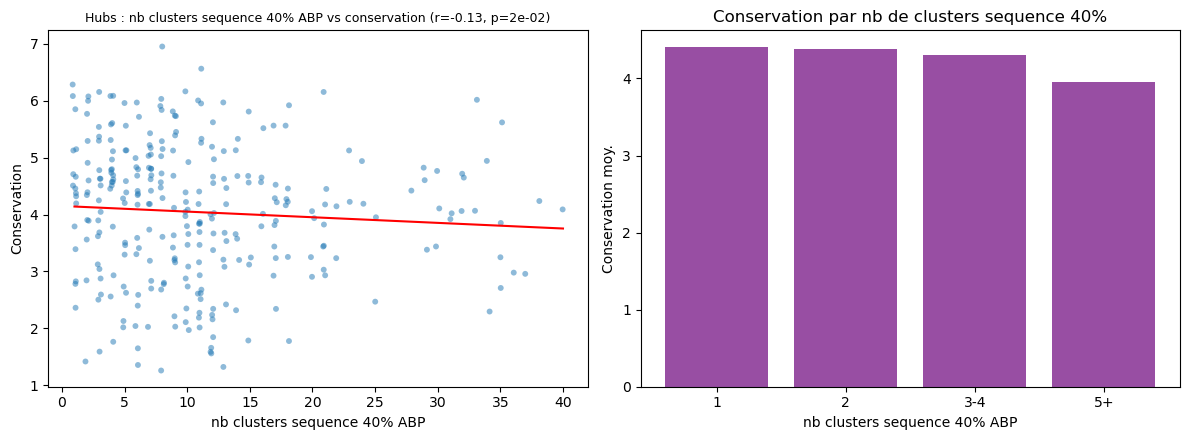

In [16]:
# Positions hub : compte par CLUSTER DE SEQUENCE (40%), pas par famille biologique nommee.
# n_seq40 = nb de clusters de sequence 40% distincts d'ABP en contact (= "familles" sequence,
# meme definition que abp_analysis.ipynb). On garde aussi n_seq70 (cluster 70%) en repere.
iid2seq40 = di.set_index('interaction_id')['s2_sequence_cluster_40']
iid2seq70 = di.set_index('interaction_id')['s2_sequence_cluster_70']
OBS_het['seqclus40'] = OBS_het['interaction_id'].map(iid2seq40)
OBS_het['seqclus70'] = OBS_het['interaction_id'].map(iid2seq70)
hub = OBS_het.groupby('canon').agg(n_seq40=('seqclus40', 'nunique'),
                                   n_seq70=('seqclus70', 'nunique')).reset_index()
hub['pos'] = hub['canon'].map(canon2seq); hub = hub.dropna(subset=['pos']); hub['pos'] = hub['pos'].astype(int)
hub['conservation'] = hub['pos'].map(cons); hub = hub.dropna(subset=['conservation'])
r, p = stats.spearmanr(hub['n_seq40'], hub['conservation'])
r70, p70 = stats.spearmanr(hub['n_seq70'], hub['conservation'])
print(f'nb clusters sequence 40% ABP vs conservation : r={r:+.3f} (p={p:.1e}) n={len(hub)}')
print(f'nb clusters sequence 70% ABP vs conservation : r={r70:+.3f} (p={p70:.1e})')
hub['bin'] = pd.cut(hub['n_seq40'], [0, 1, 2, 4, 100], labels=['1', '2', '3-4', '5+'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(hub['n_seq40'] + np.random.uniform(-0.15, 0.15, len(hub)), hub['conservation'], s=18, alpha=0.5, edgecolor='none')
z = np.polyfit(hub['n_seq40'], hub['conservation'], 1); xx = np.linspace(hub['n_seq40'].min(), hub['n_seq40'].max(), 30)
axes[0].plot(xx, np.polyval(z, xx), 'r-')
axes[0].set_title(f'Hubs : nb clusters sequence 40% ABP vs conservation (r={r:+.2f}, p={p:.0e})', fontsize=9)
axes[0].set_xlabel('nb clusters sequence 40% ABP'); axes[0].set_ylabel('Conservation')
gb = hub.groupby('bin', observed=True)['conservation'].mean()
axes[1].bar(gb.index.astype(str), gb.values, color='#984ea3')
axes[1].set_xlabel('nb clusters sequence 40% ABP'); axes[1].set_ylabel('Conservation moy.'); axes[1].set_title('Conservation par nb de clusters sequence 40%')
plt.tight_layout(); plt.show()


## 12. Figure de synthèse — tous les résultats clés

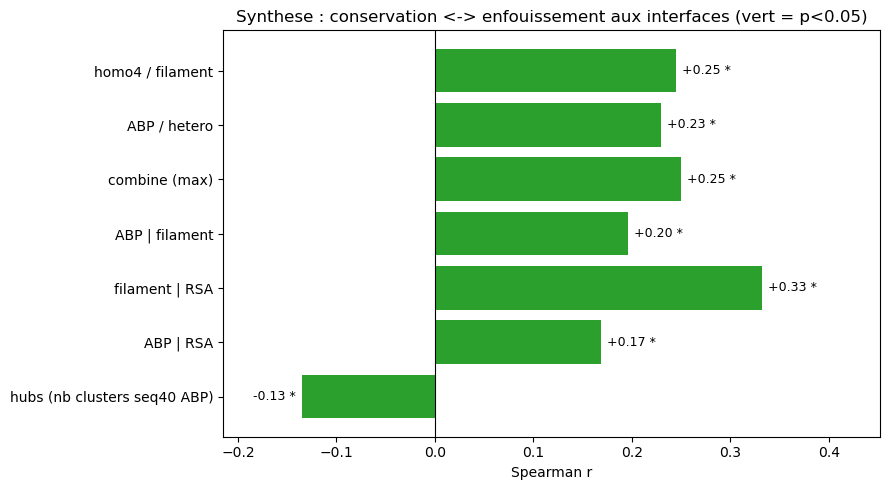

In [17]:
results = []
for col, lab in [('homo_asa', 'homo4 / filament'), ('hetero_asa', 'ABP / hetero'), ('combined_asa', 'combine (max)')]:
    s = df[df[col] > 0]; r, p = stats.spearmanr(s[col], s['conservation']); results.append((lab, r, p))
si = df[df.at_interface]
r, p, _ = partial_spearman(si, 'hetero_asa', 'conservation', 'homo_asa'); results.append(('ABP | filament', r, p))
sub = df.dropna(subset=['rsa'])
r, p, _ = partial_spearman(sub[sub.homo_asa > 0], 'homo_asa', 'conservation', 'rsa'); results.append(('filament | RSA', r, p))
r, p, _ = partial_spearman(sub[sub.hetero_asa > 0], 'hetero_asa', 'conservation', 'rsa'); results.append(('ABP | RSA', r, p))
r, p = stats.spearmanr(hub['n_seq40'], hub['conservation']); results.append(('hubs (nb clusters seq40 ABP)', r, p))
results = results[::-1]
labs = [x[0] for x in results]; rs = [x[1] for x in results]; ps = [x[2] for x in results]
cols = ['#2ca02c' if pp < 0.05 else '#bbbbbb' for pp in ps]
fig, ax = plt.subplots(figsize=(9, 5)); ax.barh(labs, rs, color=cols)
for i, (rr, pp) in enumerate(zip(rs, ps)):
    ax.text(rr + (0.006 if rr >= 0 else -0.006), i, f'{rr:+.2f} ' + ('*' if pp < 0.05 else 'ns'),
            va='center', ha='left' if rr >= 0 else 'right', fontsize=9)
ax.axvline(0, color='k', lw=0.8); ax.set_xlim(min(rs) - 0.08, max(rs) + 0.12); ax.set_xlabel('Spearman r')
ax.set_title('Synthese : conservation <-> enfouissement aux interfaces (vert = p<0.05)')
plt.tight_layout(); plt.show()

## Heatmaps binaires — résidus en interaction le long de la séquence

Un résidu est marqué s'il est en interaction (au-dessus d'un seuil de % ASA moyen). Seuil 0 = au moins une fois ; seuil 2% = version robuste recommandée (retire les contacts anecdotiques).

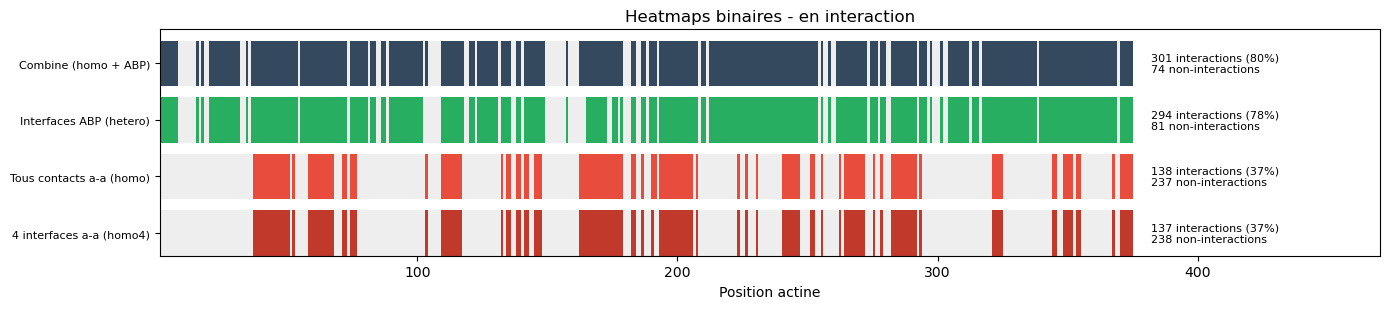

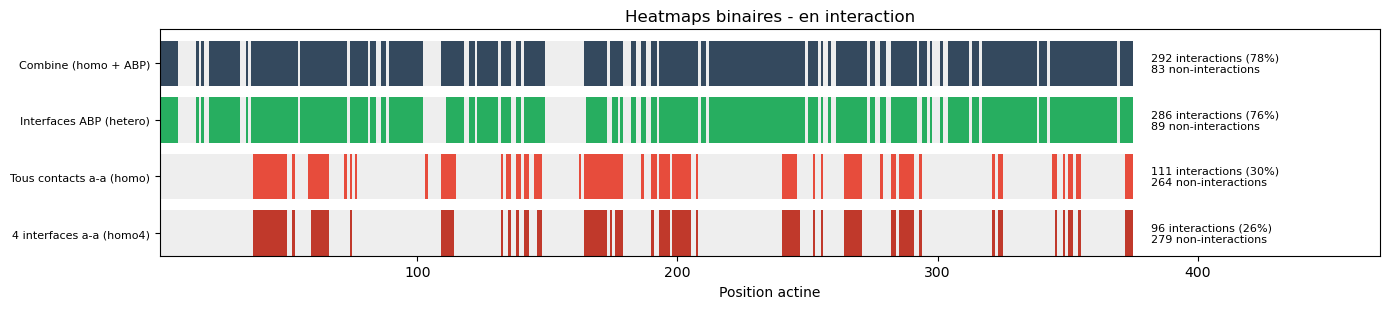

Nb de positions en interaction selon le seuil (% ASA moyen) :
 seuil |  homo4 | homo tous |   ABP | combine
     0 |    137 |       138 |   295 |     302
     1 |    104 |       117 |   290 |     297
     2 |     96 |       111 |   287 |     293
     5 |     87 |       106 |   275 |     284
    10 |     80 |        86 |   231 |     256


In [18]:
def plot_binary(TH):
    tracks = [('4 interfaces a-a (homo4)', df['homo_asa'], '#c0392b'),
              ('Tous contacts a-a (homo)', df['homo_all_asa'], '#e74c3c'),
              ('Interfaces ABP (hetero)', df['hetero_asa'], '#27ae60'),
              ('Combine (homo + ABP)', df['combined_asa'], '#34495e')]
    pos = np.arange(1, 376)
    fig, ax = plt.subplots(figsize=(14, 3.2))
    for i, (name, ser, col) in enumerate(tracks):
        ax.broken_barh([(1, 374)], (i, 0.8), facecolors='#eeeeee')
        b = ser.reindex(pos).fillna(0).values > TH
        ax.broken_barh([(p, 1) for p, v in zip(pos, b) if v], (i, 0.8), facecolors=col)
        nin = int(b.sum())
        ax.text(382, i + 0.4, f'{nin} interactions ({100*(nin)/375:.0f}%) \n{375 - nin} non-interactions', va='center', fontsize=8)
    ax.set_yticks([i + 0.4 for i in range(len(tracks))]); ax.set_yticklabels([t[0] for t in tracks], fontsize=8)
    ax.set_xlim(1, 470); ax.set_ylim(0, len(tracks)); ax.set_xlabel('Position actine')
    ax.set_title(f'Heatmaps binaires - en interaction')
    plt.tight_layout(); plt.show()

plot_binary(0.0)   # au moins une fois
plot_binary(2.0)   # seuil robuste recommande

print('Nb de positions en interaction selon le seuil (% ASA moyen) :')
print(f"{'seuil':>6} | {'homo4':>6} | {'homo tous':>9} | {'ABP':>5} | {'combine':>7}")
for TH in [0, 1, 2, 5, 10]:
    a = (df['homo_asa'] > TH).sum(); b = (df['homo_all_asa'] > TH).sum()
    c = (df['hetero_asa'] > TH).sum(); d = (df['combined_asa'] > TH).sum()
    print(f'{TH:>6} | {a:>6} | {b:>9} | {c:>5} | {d:>7}')

## Enrichissement en résidus `sensitive` (ProteoCast) — interfaces & familles

Analyse catégorielle robuste : pour chaque interface / famille d'ABP, fraction de résidus classés `sensitive` par ProteoCast, comparée au reste de la **surface** (RSA≥20%, donc cœur exclu → pas de biais). Test de Fisher (odds-ratio, p).

Baseline SURFACE : 108/184 sensitive (59%)

--- Interfaces actine-actine ---
  6685_1: 50% sensitive (n=32) | OR=0.65 p=0.325
  6685_2: 56% sensitive (n=32) | OR=0.89 p=0.844
  6685_3: 60% sensitive (n=30) | OR=1.07 p=1.000
  6685_4: 76% sensitive (n=34) | OR=2.70 p=0.021
  TOUS contacts homo (regroupes): 61% sensitive (n=102) | OR=1.21 p=0.549

--- Familles ABP ---
  Cofiline/ADF: 79% sensitive (n=57) | OR=3.81 p=0.000
  Spectrine/actinine: 71% sensitive (n=59) | OR=2.21 p=0.024
  Vinculine/Catenine: 70% sensitive (n=80) | OR=2.33 p=0.007
  Formine: 62% sensitive (n=86) | OR=1.26 p=0.458
  Myosine: 61% sensitive (n=72) | OR=1.18 p=0.647
  Autre: 60% sensitive (n=159) | OR=1.37 p=0.516
  Arp2/3: 58% sensitive (n=121) | OR=0.90 p=0.875
  Tropomoduline: 58% sensitive (n=92) | OR=0.91 p=0.881
  Toxine bacterienne: 55% sensitive (n=115) | OR=0.65 p=0.216
  Gelsoline/Villine: 55% sensitive (n=84) | OR=0.74 p=0.368
  Dematine: 53% sensitive (n=94) | OR=0.63 p=0.136
  Coronine: 51% sensitive 

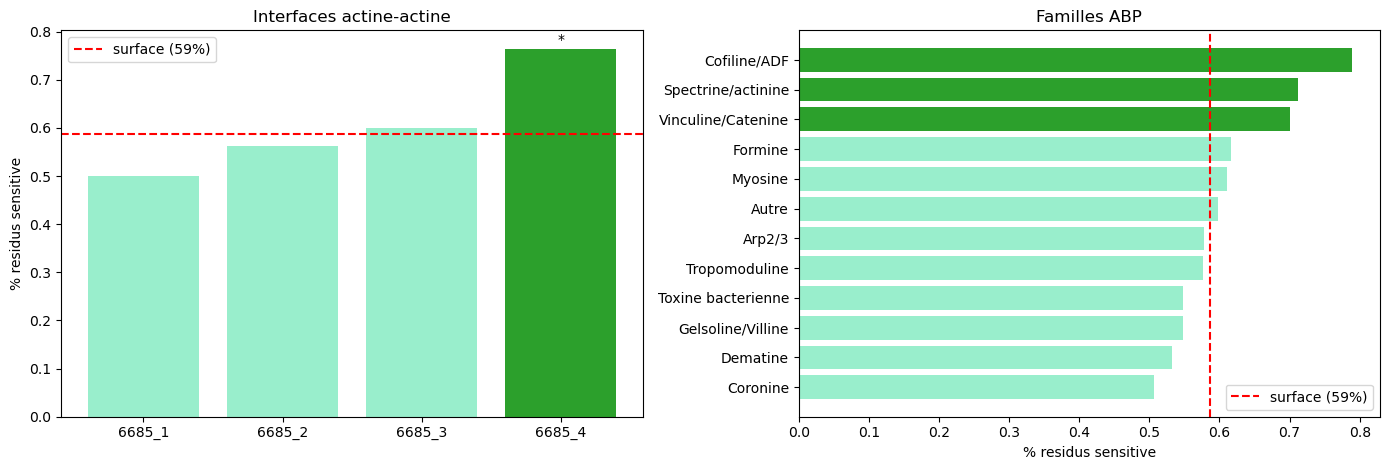

In [19]:
from scipy.stats import fisher_exact
rc = res.set_index('Residue')['residue_class']
surface_set = set(df.loc[df['rsa'] >= 0.20, 'Residue'])
base = rc.reindex(sorted(surface_set))
base_a = int((base == 'sensitive').sum()); base_b = int((base == 'tolerant').sum())
print(f"Baseline SURFACE : {base_a}/{base_a+base_b} sensitive ({base_a/(base_a+base_b):.0%})\n")

def enrich(positions):
    pos = [p for p in positions if p in surface_set and p in rc.index]
    s = rc.reindex(pos)
    a = int((s == 'sensitive').sum()); b = int((s == 'tolerant').sum())
    c, d = base_a - a, base_b - b
    if a + b == 0 or min(c, d) < 0:
        return len(pos), float('nan'), float('nan'), float('nan')
    OR, pf = fisher_exact([[a, b], [c, d]])
    return a + b, a / (a + b), OR, pf

# --- 4 interfaces actine-actine ---
print('--- Interfaces actine-actine ---')
res_bs = []
for bs in MAIN_BS:
    n, fr, OR, pf = enrich(bs_profiles[bs].dropna().index)
    res_bs.append((bs, n, fr, OR, pf)); print(f'  {bs}: {fr:.0%} sensitive (n={n}) | OR={OR:.2f} p={pf:.3f}')
n, fr, OR, pf = enrich(df.loc[df.homo_all_asa > 0, 'Residue'])
print(f'  TOUS contacts homo (regroupes): {fr:.0%} sensitive (n={n}) | OR={OR:.2f} p={pf:.3f}')
# --- familles ABP ---
print('\n--- Familles ABP ---')
res_fam = []
for f, sub in OBS_het.groupby('family'):
    if sub['interaction_id'].nunique() < 3: continue
    prof = equitable(sub); poss = [canon2seq[c] for c in prof.index if c in canon2seq]
    n, fr, OR, pf = enrich(poss)
    if n >= 10: res_fam.append((f, n, fr, OR, pf))
res_fam.sort(key=lambda x: -x[2])
for f, n, fr, OR, pf in res_fam:
    print(f'  {f}: {fr:.0%} sensitive (n={n}) | OR={OR:.2f} p={pf:.3f}')

# --- figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
b = base_a/(base_a+base_b)
xb=[r[0] for r in res_bs]; yb=[r[2] for r in res_bs]; pb=[r[4] for r in res_bs]
axes[0].bar(xb, yb, color=['#2ca02c' if pp<0.05 else '#9ec' for pp in pb])
axes[0].axhline(b, color='red', ls='--', label=f'surface ({b:.0%})')
axes[0].set_ylabel('% residus sensitive'); axes[0].set_title('Interfaces actine-actine'); axes[0].legend()
for i,(_,_,fr,_,pf) in enumerate(res_bs): axes[0].text(i,fr+0.01,('*' if pf<0.05 else ''),ha='center')
xf=[r[0] for r in res_fam][::-1]; yf=[r[2] for r in res_fam][::-1]; pf2=[r[4] for r in res_fam][::-1]
axes[1].barh(xf, yf, color=['#2ca02c' if pp<0.05 else '#9ec' for pp in pf2])
axes[1].axvline(b, color='red', ls='--', label=f'surface ({b:.0%})')
axes[1].set_xlabel('% residus sensitive'); axes[1].set_title('Familles ABP'); axes[1].legend()
plt.tight_layout(); plt.show()

## Enrichissement sensitive par ZONE de binding-site de l'actine

Regroupement par **cluster de binding-site de l'actine** (`s1_binding_site_cluster_data_70`, ex. 6685_0) = une zone de l'actine, pouvant être liée par **plusieurs ABP**. Étiqueté par les ABP qui s'y lient. Hétéro uniquement, ≥5 interactions. Enrichissement `sensitive` vs surface (Fisher, OR Haldane).

Baseline surface : 59% sensitive | zones retenues (>= 1 interactions) : 141

                               ABP     zone  n_intx  n_res  pct_sensitive    OR     p
         Tropomyosin alpha-1 chain 6685_252       2      3           1.00  5.08 0.269
                           Talin-1 6685_249       3      8           1.00 12.94 0.022
                 Inverted formin-2 6685_219       2      7           1.00 11.31 0.043
Maltose/maltodextrin-binding perip 6685_120       1     21           0.95 11.66 0.000
                   Tropomyosin-1.9 6685_161       2     13           0.92  6.52 0.016
Inositol-trisphosphate 3-kinase A/ 6685_121      23     20           0.90  6.09 0.003
Actin-related protein 2/3 complex  6685_144       9     19           0.89  5.70 0.005
Catenin alpha-1/Inositol-trisphosp 6685_102       9     25           0.88  5.46 0.001
Actin-related protein 2/3 complex   6685_15      16     17           0.88  4.94 0.009
Isoform A2 of Troponin T/Troponin  6685_138       4     22     

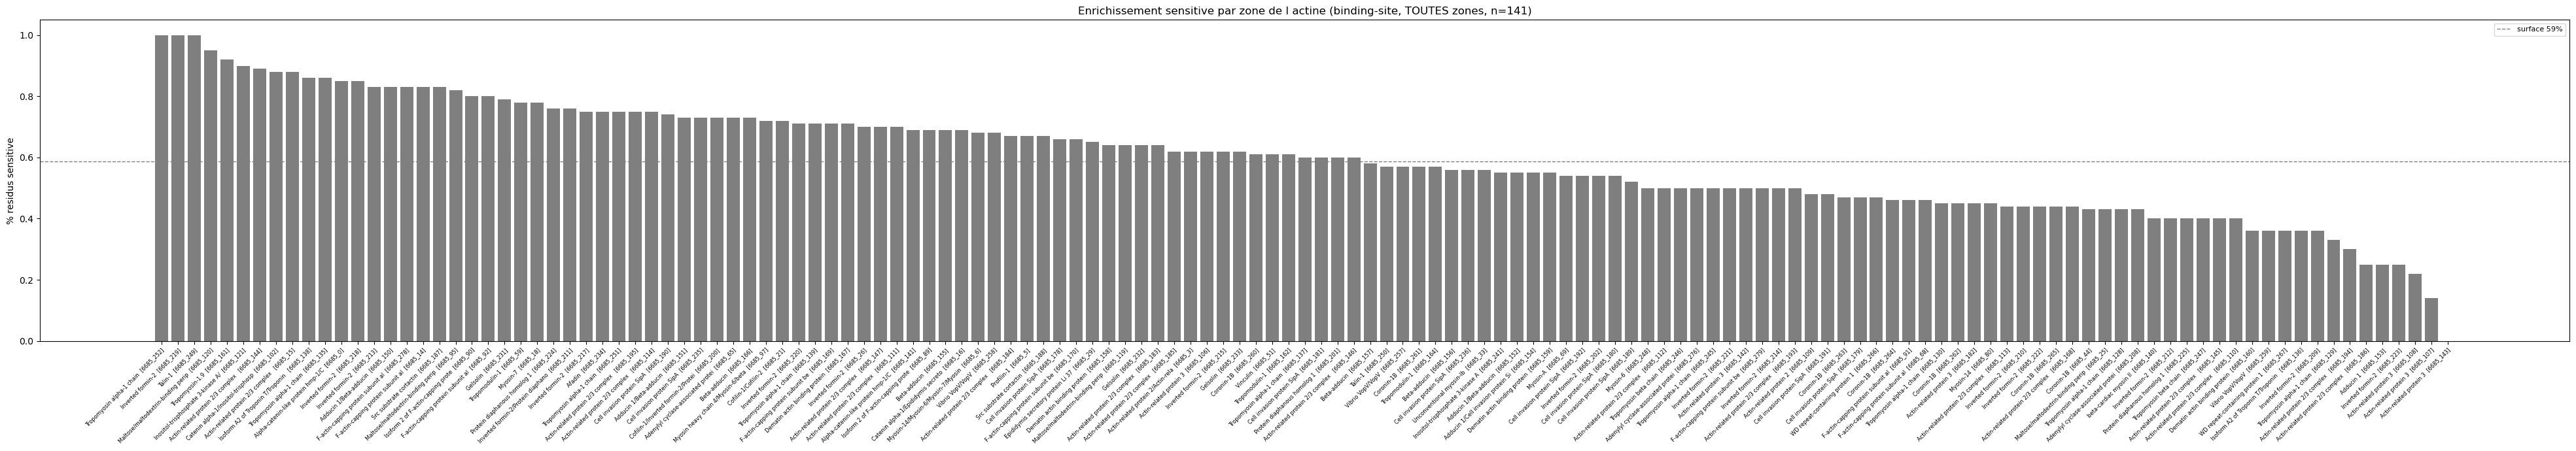

In [20]:
from scipy.stats import fisher_exact
MIN_INTX = 1  # TOUS les binding-sites (avant: 5)
di_bs = pd.read_csv(T1).merge(
    df_all[['subunit_1', 'subunit_2', 's2_actine', 'subunit_2_title', 's1_binding_site_cluster_data_70']].drop_duplicates(),
    left_on=['chain_A_id', 'chain_B_id'], right_on=['subunit_1', 'subunit_2'], how='left')
di_bs['s2_actine'] = di_bs['s2_actine'].fillna(False).astype(bool)
het_i = di_bs[~di_bs['s2_actine']].dropna(subset=['s1_binding_site_cluster_data_70'])
iid2bs = het_i.set_index('interaction_id')['s1_binding_site_cluster_data_70']
zone_size = het_i.groupby('s1_binding_site_cluster_data_70')['interaction_id'].nunique()
zones = zone_size[zone_size >= MIN_INTX].index

def clean(t): return str(t).split(',')[0].strip()
zone_prot = {z: sorted({clean(t) for t in het_i[het_i.s1_binding_site_cluster_data_70 == z]['subunit_2_title']})
             for z in zones}

OBS_het = OBS[OBS.itype == 'hetero'].copy()
OBS_het['zone'] = OBS_het['interaction_id'].map(iid2bs)
rc = res.set_index('Residue')['residue_class']
surface_set = set(df.loc[df['rsa'] >= 0.20, 'Residue'])
base = rc.reindex(sorted(surface_set)); base_a = int((base == 'sensitive').sum()); base_b = int((base == 'tolerant').sum())

rows = []
for z in zones:
    cc = OBS_het[OBS_het.zone == z]['canon'].unique()
    poss = [canon2seq[c] for c in cc if c in canon2seq and canon2seq[c] in surface_set]
    a = sum(rc.get(x) == 'sensitive' for x in poss); b = sum(rc.get(x) == 'tolerant' for x in poss)
    if a + b < 1:   # TOUT : seul garde-fou = eviter la division par zero
        continue
    c, d = base_a - a, base_b - b
    _, pf = fisher_exact([[a, b], [max(c, 0), max(d, 0)]])
    OR = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
    rows.append({'ABP': ('/'.join(zone_prot[z]))[:34], 'zone': z, 'n_intx': int(zone_size[z]),
                 'n_res': a + b, 'pct_sensitive': round(a / (a + b), 2), 'OR': round(OR, 2), 'p': round(pf, 3)})
tab = pd.DataFrame(rows).sort_values('pct_sensitive', ascending=False)
print(f"Baseline surface : {base_a/(base_a+base_b):.0%} sensitive | zones retenues (>= {MIN_INTX} interactions) : {len(tab)}\n")
print(tab.to_string(index=False))

tab['label'] = tab['ABP'] + '  [' + tab['zone'] + ']'
fd = tab.sort_values('pct_sensitive', ascending=False)
_bf = base_a / (base_a + base_b)
fig, ax = plt.subplots(figsize=(max(8, 0.28 * len(fd)), 7))
ax.bar(fd['label'], fd['pct_sensitive'], color='#7f7f7f')   # barres verticales, unicolores
ax.axhline(_bf, color='grey', ls='--', lw=1, label=f'surface {_bf:.0%}')
ax.set_ylabel('% residus sensitive')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=6)  # etiquettes en biais
ax.legend(fontsize=8, loc='upper right')
ax.set_title(f'Enrichissement sensitive par zone de l actine (binding-site, TOUTES zones, n={len(fd)})')
plt.tight_layout(); plt.show()

## 13. Export

In [21]:
out = ROOT / 'data' / 'proteocast'; out.mkdir(parents=True, exist_ok=True)
cols = ['Residue', 'canon', 'conservation', 'mean_vs', 'frac_impactful', 'residue_class',
        'homo_asa', 'hetero_asa', 'combined_asa', 'rsa', 'at_homo', 'at_hetero', 'at_interface']
df[cols].to_csv(out / 'conservation_vs_asa_per_position.csv', index=False)
print('ecrit :', out / 'conservation_vs_asa_per_position.csv')

ecrit : /Users/user/Desktop/stage/actin_project/data/proteocast/conservation_vs_asa_per_position.csv
